<a href="https://colab.research.google.com/github/SuperGlent/Notebooks/blob/main/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this notebook I will consider neural network architecture called Variational Autoencoders. It differ from ordinary autoencoders by tuning encoder to squeeze data with normal distr parametrs as adding KL Divergency to an ordinary net loss. Those networks stands as fundament for state of art like transformers and a lot of architectures of modern NN.

In [ ]:
!pip install tensorflow==2.15

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.15


In [ ]:
#import package for downloading the dataset
import gdown

In [ ]:
gdown.download("https://storage.yandexcloud.net/aiueducation/Content/advanced/l1/cartoonset10k.zip") #download cartoon images dataset


Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/advanced/l1/cartoonset10k.zip
To: /content/cartoonset10k.zip
100%|██████████| 479M/479M [00:21<00:00, 22.0MB/s]


'cartoonset10k.zip'

In [ ]:
!unzip -qo /content/cartoonset10k.zip -d data/

In [ ]:
#import necessary packages
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Conv2D, Conv2DTranspose, Input, Dropout, BatchNormalization, LeakyReLU, MaxPool2D, Lambda, Reshape, Flatten
import keras.backend as K
import keras
from keras.models import Model
from keras.losses import MeanSquaredError
import tensorflow as tf
import re

Okay, let's preproccess our dataset.

In [ ]:
#have a look what is datafiles formats are. We have to get rid of csv files.
for i, k in enumerate(os.listdir("/content/data")):
  if i < 20:
    print(k)

cs10429351266642727732.csv
cs10536151251414041459.csv
cs11010494720246645571.png
cs10145638108753347508.csv
cs10576399398861922266.png
cs10928412322494391494.png
cs10047839680157143112.csv
cs10603281065040429969.csv
cs10740480247153589385.csv
cs10054041655224050719.png
cs10755196293694292592.png
cs10156624152868614613.png
cs10055919131009398679.png
cs11456199073981449871.png
cs10054463285176832318.png
cs10000849938093558363.png
cs11135961484745230025.csv
cs11405597438335548904.png
cs10681911017644376661.csv
cs10825138291833950512.png


In [ ]:
#Only png left)
readmy_file = os.listdir("/content/data")
for fil in readmy_file:
  find_csv = re.search(".csv", fil)
  if find_csv != None:
    os.remove("/content/data/"+fil)
    readmy_file.remove(fil)

for i, k in enumerate(os.listdir("/content/data")):
  if i < 20:
    print(k)


cs11010494720246645571.png
cs10576399398861922266.png
cs10928412322494391494.png
cs10054041655224050719.png
cs10755196293694292592.png
cs10156624152868614613.png
cs10055919131009398679.png
cs11456199073981449871.png
cs10054463285176832318.png
cs10000849938093558363.png
cs11405597438335548904.png
cs10825138291833950512.png
cs10943100995328575097.png
cs11043886194725941625.png
cs1034382090713952562.png
cs10428405448262326053.png
cs11194529339394401190.png
cs11046382282585068978.png
cs10044711661362581498.png
cs11147047648987984015.png


In [ ]:
img = Image.open("/content/data/"+readmy_file[0])
print(img)

<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=500x500 at 0x7C7E42820260>


In [ ]:
print(len(readmy_file)) #dataset volume, it's strange, there should be 10000 samples. Let's see...

10659


In [ ]:
#image as np array
img = np.array(img)
print(img, img.shape)

[[[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]

 [[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]

 [[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]

 ...

 [[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]

 [[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]

 [[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]] (500, 500, 4)


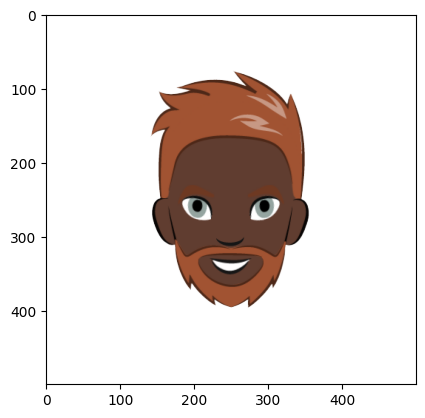

In [ ]:
#Take a look for single image
plt.imshow(img)

In [ ]:
#All images as np arrays. I collided with problem with lefted .csv files, let's just except the error and define new dataset volume :(
images = []

for png in readmy_file:
  try:
    img_pil = Image.open("/content/data/"+png).resize((64, 64))
    img_arr = np.array(img_pil) / 255.0
    images.append(img_arr[..., :3])

  except Exception as error:
    pass

  finally:
    continue

cannot identify image file '/content/data/cs10051092731244549058.csv'
cannot identify image file '/content/data/cs10322257745788403030.csv'
cannot identify image file '/content/data/cs11339969133805974949.csv'
cannot identify image file '/content/data/cs11047443056960985574.csv'
cannot identify image file '/content/data/cs10725500940098825275.csv'
cannot identify image file '/content/data/cs11442012755356216533.csv'
cannot identify image file '/content/data/cs10433873479498750733.csv'
cannot identify image file '/content/data/cs10932058252516828691.csv'
cannot identify image file '/content/data/cs10098175938377151025.csv'
cannot identify image file '/content/data/cs1102042615205617764.csv'
cannot identify image file '/content/data/cs10334029705471552725.csv'
cannot identify image file '/content/data/cs10679763891164203345.csv'
cannot identify image file '/content/data/cs10272416400378369048.csv'
cannot identify image file '/content/data/cs10864726220096882036.csv'
cannot identify image

In [ ]:
print(len(images)) #here we go!

10000


In [ ]:
input_shape = (64, 64, 3)
latent_dim = 2 #dimension of encder outputs, it should predict mean and log of varience of data.
batch_size = 10

# Encoder network
encoder_inputs = Input(shape=input_shape)
x = Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_inputs)
x = Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.math.exp(0.5 * z_log_var) * epsilon

z = Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

# Decoder
latent_inputs = Input(shape=(latent_dim,))
x = Dense(16 * 16 * 64, activation='relu')(latent_inputs)
x = Reshape((16, 16, 64))(x)
x = Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
x = Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
decoder_outputs = Conv2DTranspose(3, 3, activation='sigmoid', padding='same')(x)
decoder = Model(latent_inputs, decoder_outputs, name='decoder')

# VAE Model
outputs = decoder(encoder(encoder_inputs)[2])
vae = Model(encoder_inputs, outputs, name='vae')

In [ ]:
import keras
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)

        kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        kl_loss = tf.reduce_mean(kl_loss)
        kl_loss *= -0.5
        self.add_loss(kl_loss)
        return reconstructed

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.MSE(data, reconstruction),
                    axis=(0, 1, 2)
                )
            )
            reconstruction_loss *= 64 * 64 * 3

            # KL divergence
            kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            kl_loss = -0.5 * tf.reduce_sum(kl_loss, axis=1)
            kl_loss = tf.reduce_mean(kl_loss)
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }


In [ ]:
print(f"Type: {type(images)}")
print(f"Shape: {np.array(images).shape}")

Type: <class 'list'>
Shape: (10000, 64, 64, 3)


In [ ]:
images = np.array(images)

In [ ]:
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')
vae.fit(images, epochs=8, batch_size=100)


Epoch 1/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 796ms/step - kl_loss: 34.1383 - loss: 64582588.0000 - reconstruction_loss: 64582556.0000
Epoch 2/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 795ms/step - kl_loss: 38.7210 - loss: 57320728.0000 - reconstruction_loss: 57320692.0000
Epoch 3/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 795ms/step - kl_loss: 40.9356 - loss: 56069516.0000 - reconstruction_loss: 56069472.0000
Epoch 4/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 80s 800ms/step - kl_loss: 42.0707 - loss: 54868132.0000 - reconstruction_loss: 54868088.0000
Epoch 5/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 796ms/step - kl_loss: 43.4519 - loss: 53728404.0000 - reconstruction_loss: 53728364.0000
Epoch 6/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 80s 796ms/step - kl_loss: 44.6717 - loss: 52662076.0000 - reconstruction_loss: 52662032.0000
Epoch 7/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 793ms/step - kl_loss: 45.5544 - loss: 51998888.0000 - reconstruction_loss: 51998840.0000
Epoch 8/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 85s 827ms/step - kl_loss: 46.7958 - l

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step


/tmp/ipython-input-4162789530.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(h[2][:, 0], h[2][:, 1], cmap='viridis')


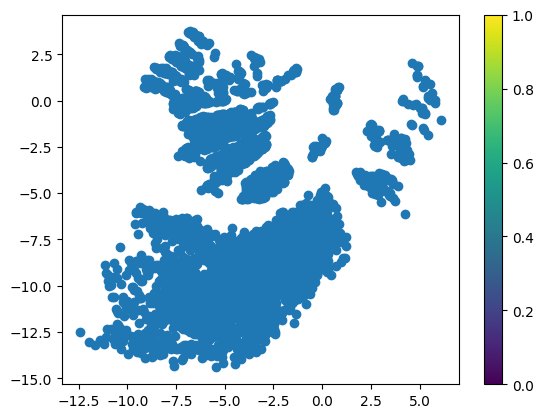

In [ ]:
h = encoder.predict(images[:5000], batch_size=100)
plt.scatter(h[2][:, 0], h[2][:, 1], cmap='viridis')
plt.colorbar()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


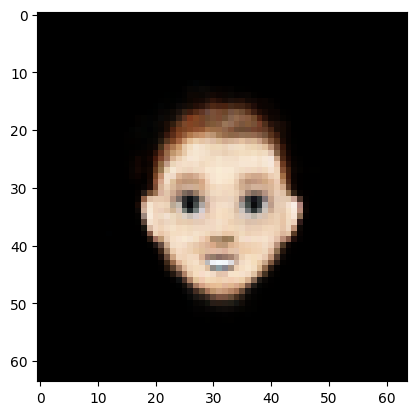

In [ ]:

decoded_img = decoder.predict(np.expand_dims(np.random.normal(loc=-10, scale=1, size=2), axis=0))
plt.imshow(decoded_img.squeeze())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


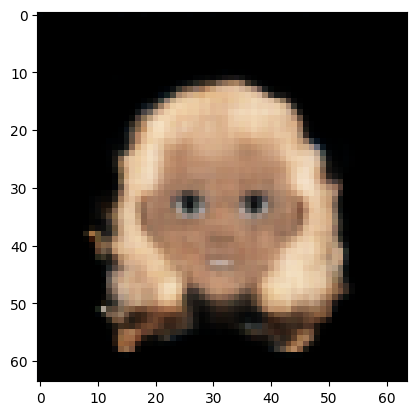

In [ ]:
decoded_img = decoder.predict(np.expand_dims(np.random.normal(loc=0, scale=1, size=2), axis=0))
plt.imshow(decoded_img.squeeze())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


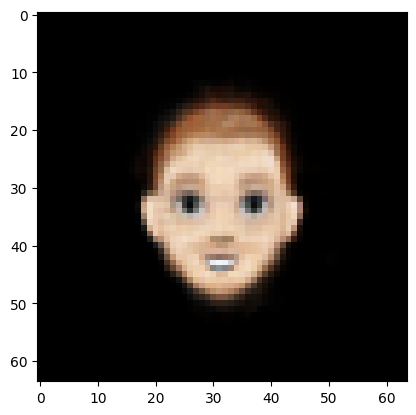

In [ ]:
decoded_img = decoder.predict(np.expand_dims(np.random.normal(loc=-7.5, scale=1, size=2), axis=0))
plt.imshow(decoded_img.squeeze())